# NCAA March Madness 2026 — Visualization Dashboard

A standalone dashboard to explore team features, matchup patterns, and model insights.

**Just run all cells** — everything loads from pre-built CSV files in `processed/`.

### Sections
1. Data Overview
2. Team Strength Landscape (Elo, Rankings, Win%)
3. Four Factors Breakdown
4. Tournament Seed Analysis
5. Feature Predictive Power
6. Feature Correlations
7. Conference Strength
8. Late-Season Momentum
9. 2025 Top Teams Profile
10. Men's vs Women's Comparison

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

# Output directory for saved figures
ASSETS_DIR = Path('..') / 'submissions' / 'assets' if Path('../submissions').exists() else Path('/home/sagemaker-user/NCAA/NCAA_March_Maddness-2026/submissions/assets')
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

# Load all processed data
PROJECT = Path('..') if Path('../processed').exists() else Path('/home/sagemaker-user/NCAA/NCAA_March_Maddness-2026')
PROCESSED = PROJECT / 'processed'
DATA = PROJECT / 'data'

# Team features
tf_m = pd.read_csv(PROCESSED / 'team_features.csv')
tf_w = pd.read_csv(PROCESSED / 'team_features_W.csv')

# Matchup features
mf_m = pd.read_csv(PROCESSED / 'matchup_features.csv')
mf_w = pd.read_csv(PROCESSED / 'matchup_features_W.csv')

# Tournament matchups
tmf_m = pd.read_csv(PROCESSED / 'tourney_matchup_features.csv')
tmf_w = pd.read_csv(PROCESSED / 'tourney_matchup_features_W.csv')

# Team lookups
men_teams = pd.read_csv(DATA / 'MTeams.csv')
women_teams = pd.read_csv(DATA / 'WTeams.csv')
men_lookup = dict(zip(men_teams['TeamID'], men_teams['TeamName']))
women_lookup = dict(zip(women_teams['TeamID'], women_teams['TeamName']))

# Seeds
seeds_m = pd.read_csv(DATA / 'MNCAATourneySeeds.csv')
seeds_w = pd.read_csv(DATA / 'WNCAATourneySeeds.csv')

# Tournament results
tourney_m = pd.read_csv(DATA / 'MNCAATourneyCompactResults.csv')
tourney_w = pd.read_csv(DATA / 'WNCAATourneyCompactResults.csv')

print(f"Men's team features:    {tf_m.shape}  (seasons {tf_m['Season'].min()}-{tf_m['Season'].max()})")
print(f"Women's team features:  {tf_w.shape}  (seasons {tf_w['Season'].min()}-{tf_w['Season'].max()})")
print(f"Men's matchups:         {len(mf_m):,}")
print(f"Women's matchups:       {len(mf_w):,}")
print(f"Men's tourney matchups: {len(tmf_m):,}")
print(f"Women's tourney matchups: {len(tmf_w):,}")
print(f"Assets will be saved to: {ASSETS_DIR.resolve()}")
print(f"\nDashboard ready.")

---
## 1. Data Overview

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Teams per season
m_counts = tf_m.groupby('Season').size()
w_counts = tf_w.groupby('Season').size()
axes[0].plot(m_counts.index, m_counts.values, 'o-', label="Men's", markersize=4)
axes[0].plot(w_counts.index, w_counts.values, 's-', label="Women's", markersize=4)
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Teams')
axes[0].set_title('Teams Per Season')
axes[0].legend()

# Games per season (from matchup data)
m_games = mf_m.groupby('Season').size()
axes[1].bar(m_games.index, m_games.values, alpha=0.7, color='steelblue')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Matchups Built')
axes[1].set_title("Men's Matchups Per Season")

# Tournament vs Regular split
labels = ['Regular Season', 'Tournament']
m_sizes = [len(mf_m[mf_m['GameType']=='Regular']), len(mf_m[mf_m['GameType']=='Tournament'])]
w_sizes = [len(mf_w[mf_w['GameType']=='Regular']), len(mf_w[mf_w['GameType']=='Tournament'])]
x = np.arange(len(labels))
axes[2].bar(x - 0.2, m_sizes, 0.35, label="Men's", alpha=0.7)
axes[2].bar(x + 0.2, w_sizes, 0.35, label="Women's", alpha=0.7)
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_ylabel('Matchup Count')
axes[2].set_title('Training Data Split')
axes[2].legend()
for i, (m, w) in enumerate(zip(m_sizes, w_sizes)):
    axes[2].text(i-0.2, m + 500, f'{m:,}', ha='center', fontsize=9)
    axes[2].text(i+0.2, w + 500, f'{w:,}', ha='center', fontsize=9)

plt.suptitle('Dataset Overview', fontsize=16, fontweight='bold')
plt.tight_layout()
fig.savefig(ASSETS_DIR / 'data_overview.png', bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {ASSETS_DIR / 'data_overview.png'}")

---
## 2. Team Strength Landscape

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Elo distribution over time (heatmap style)
season_2025 = tf_m[tf_m['Season'] == 2025]
axes[0, 0].hist(season_2025['Elo_RegSeason'], bins=40, edgecolor='black', alpha=0.7, color='teal')
axes[0, 0].axvline(1500, color='red', linestyle='--', label='Starting Elo (1500)')
axes[0, 0].axvline(season_2025['Elo_RegSeason'].mean(), color='orange', linestyle='--',
                    label=f"Mean ({season_2025['Elo_RegSeason'].mean():.0f})")
axes[0, 0].set_xlabel('Elo Rating')
axes[0, 0].set_ylabel('Number of Teams')
axes[0, 0].set_title('2025 Elo Rating Distribution')
axes[0, 0].legend()

# Win% vs Elo scatter
axes[0, 1].scatter(tf_m['WinPct'], tf_m['Elo_RegSeason'], alpha=0.05, s=8, color='steelblue')
axes[0, 1].scatter(season_2025['WinPct'], season_2025['Elo_RegSeason'],
                   alpha=0.6, s=20, color='red', label='2025', zorder=5)
axes[0, 1].set_xlabel('Win %')
axes[0, 1].set_ylabel('Elo Rating')
axes[0, 1].set_title('Win% vs Elo (Elo adjusts for schedule strength)')
axes[0, 1].legend()

# AvgMargin distribution
axes[1, 0].hist(tf_m['AvgMargin'], bins=60, edgecolor='black', alpha=0.7, color='coral')
axes[1, 0].axvline(0, color='black', linestyle='-', linewidth=2, label='Break even')
axes[1, 0].set_xlabel('Average Victory Margin')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Average Margin Distribution (All Seasons)')
axes[1, 0].legend()

# Offense vs Defense
axes[1, 1].scatter(tf_m['AvgPointsFor'], tf_m['AvgPointsAgainst'], alpha=0.05, s=8, c='gray')
axes[1, 1].scatter(season_2025['AvgPointsFor'], season_2025['AvgPointsAgainst'],
                   alpha=0.6, s=20, c='red', label='2025', zorder=5)
axes[1, 1].plot([40, 100], [40, 100], 'k--', alpha=0.5, label='Equal scoring')
axes[1, 1].set_xlabel('Avg Points For (Offense)')
axes[1, 1].set_ylabel('Avg Points Against (Defense)')
axes[1, 1].set_title('Offense vs Defense (below line = good team)')
axes[1, 1].legend()

plt.suptitle('Team Strength Landscape', fontsize=16, fontweight='bold')
plt.tight_layout()
fig.savefig(ASSETS_DIR / 'team_strength.png', bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {ASSETS_DIR / 'team_strength.png'}")

---
## 3. Four Factors (Dean Oliver)

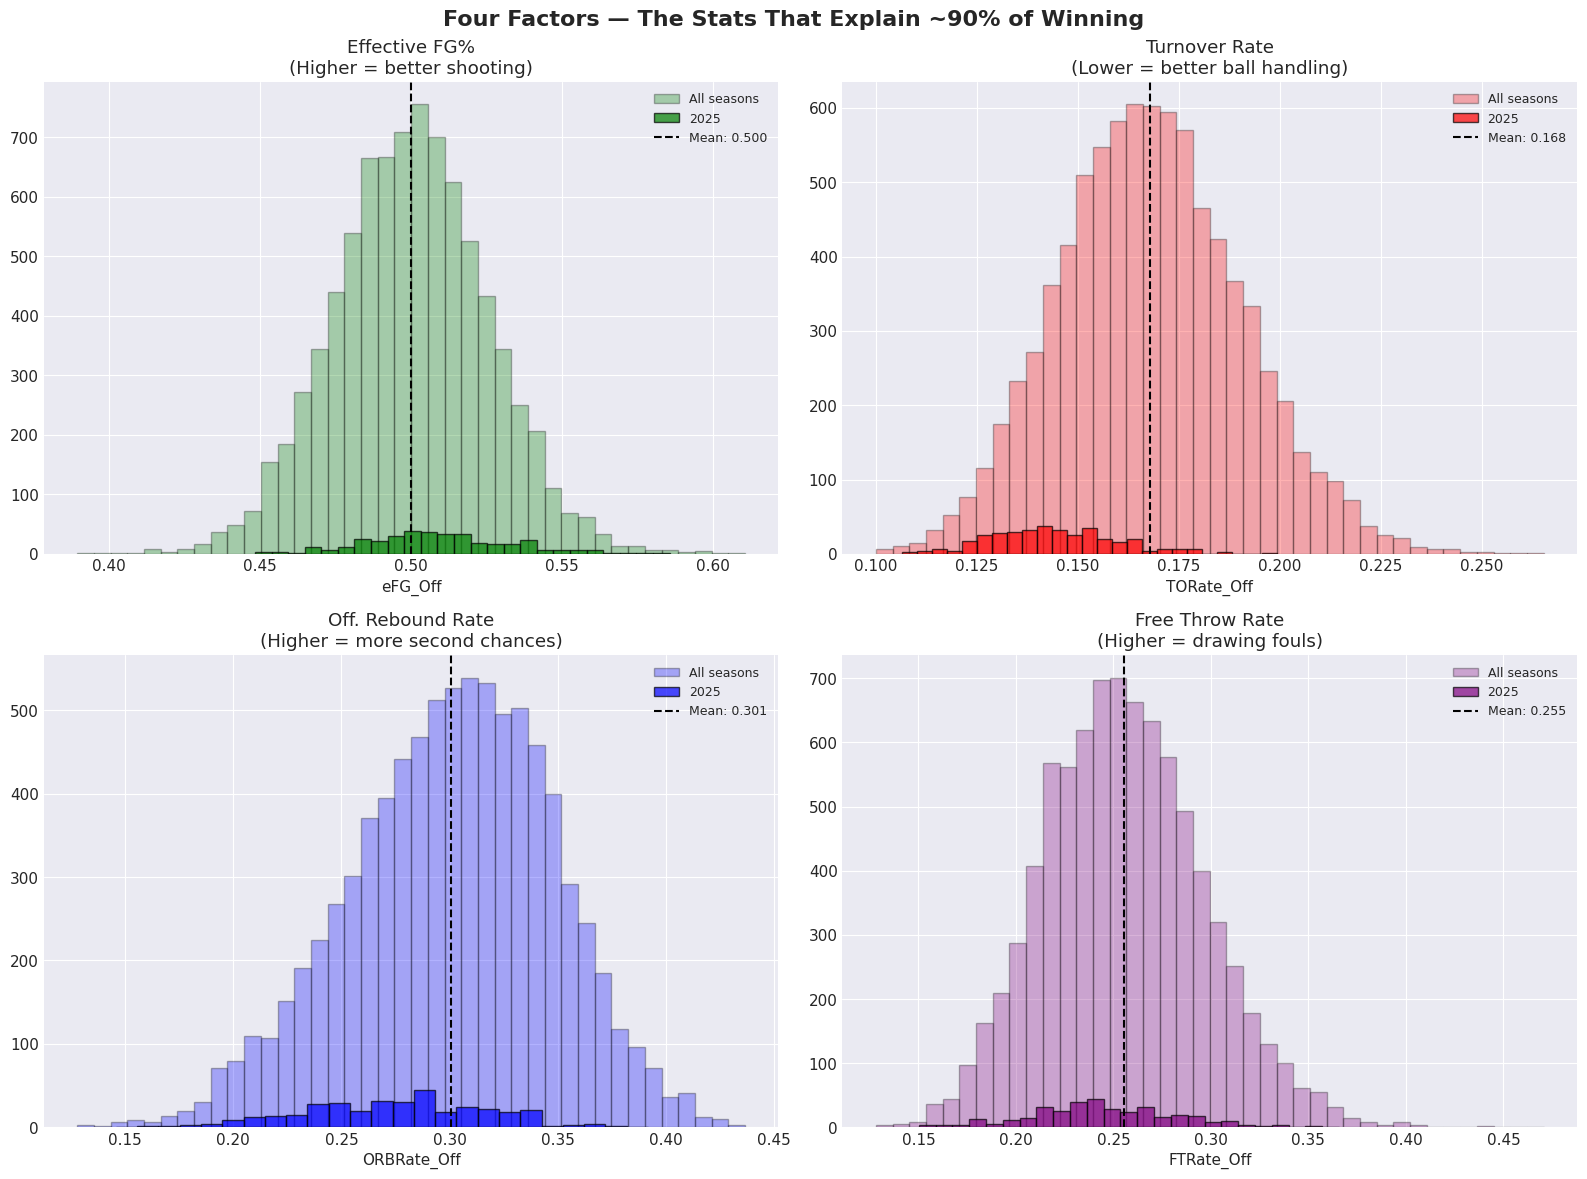

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

factors = [
    ('eFG_Off', 'Effective FG%', 'Higher = better shooting', 'green'),
    ('TORate_Off', 'Turnover Rate', 'Lower = better ball handling', 'red'),
    ('ORBRate_Off', 'Off. Rebound Rate', 'Higher = more second chances', 'blue'),
    ('FTRate_Off', 'Free Throw Rate', 'Higher = drawing fouls', 'purple')
]

for ax, (col, title, desc, color) in zip(axes.flatten(), factors):
    # All seasons
    ax.hist(tf_m[col], bins=40, edgecolor='black', alpha=0.3, color=color, label='All seasons')
    # 2025 overlay
    ax.hist(season_2025[col], bins=25, edgecolor='black', alpha=0.7, color=color, label='2025')
    ax.axvline(tf_m[col].mean(), color='black', linestyle='--',
               label=f'Mean: {tf_m[col].mean():.3f}')
    ax.set_xlabel(col)
    ax.set_title(f'{title}\n({desc})')
    ax.legend(fontsize=9)

plt.suptitle("Four Factors — The Stats That Explain ~90% of Winning", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Tournament Seed Analysis

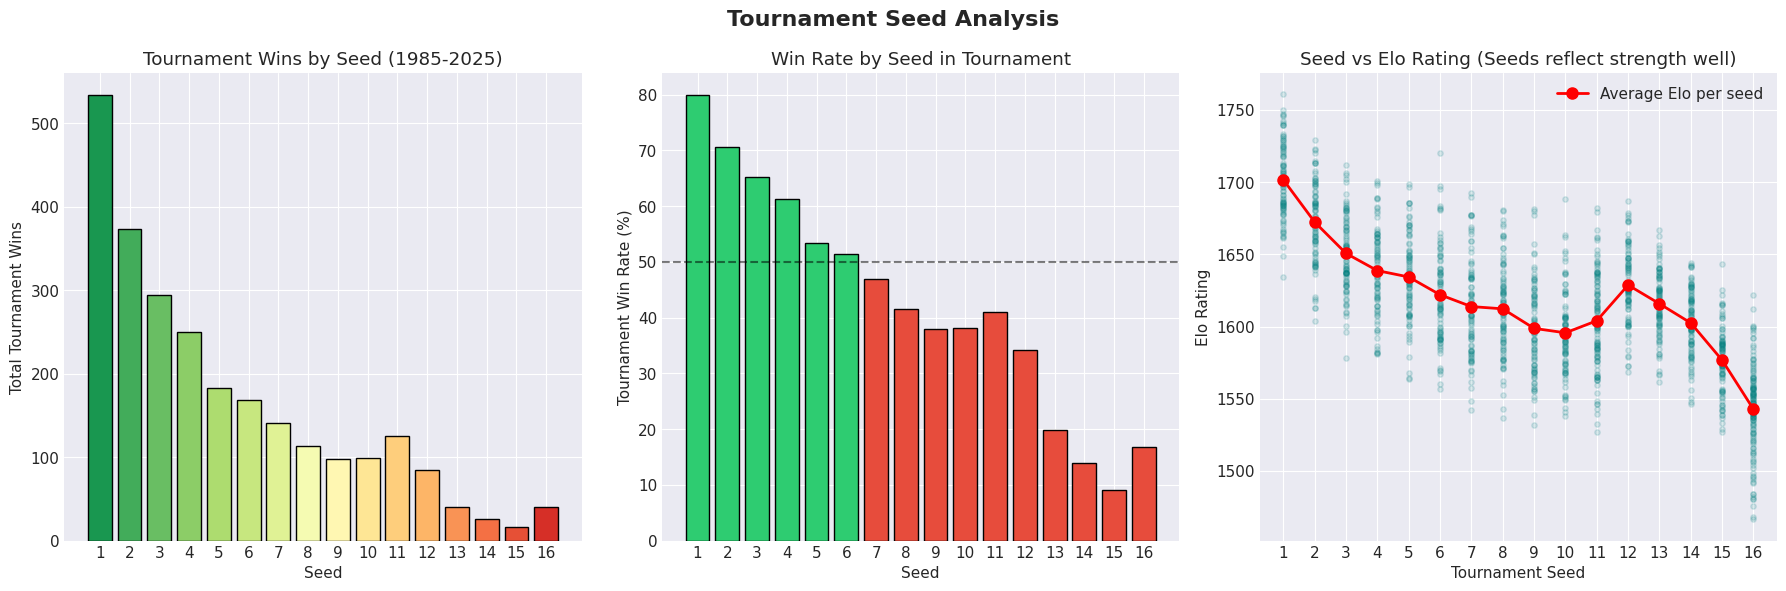

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Seed extract
seeds_m['SeedNum'] = seeds_m['Seed'].str[1:3].astype(int)

# Tournament wins by seed
tourney_with_seed = tourney_m.merge(seeds_m[['Season', 'TeamID', 'SeedNum']],
                                     left_on=['Season', 'WTeamID'],
                                     right_on=['Season', 'TeamID'], how='left')
wins_by_seed = tourney_with_seed.groupby('SeedNum').size().reset_index(name='Wins')

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 16))
axes[0].bar(wins_by_seed['SeedNum'], wins_by_seed['Wins'],
            color=colors, edgecolor='black')
axes[0].set_xlabel('Seed')
axes[0].set_ylabel('Total Tournament Wins')
axes[0].set_title('Tournament Wins by Seed (1985-2025)')
axes[0].set_xticks(range(1, 17))

# Win rate by seed matchup (1 vs 16, 2 vs 15, etc.)
# First round matchups
first_round = [(1,16), (2,15), (3,14), (4,13), (5,12), (6,11), (7,10), (8,9)]
matchup_labels = []
higher_seed_wins = []

for high, low in first_round:
    # Count games where higher seed won
    w_high = tourney_with_seed[
        (tourney_with_seed['SeedNum'] == high)
    ].shape[0]
    
    l_seed = tourney_m.merge(seeds_m[['Season', 'TeamID', 'SeedNum']],
                             left_on=['Season', 'LTeamID'],
                             right_on=['Season', 'TeamID'], how='left')
    w_low_in_matchup = l_seed[l_seed['SeedNum'] == high].shape[0]  # times higher seed lost
    
    matchup_labels.append(f'{high} vs {low}')

# Simpler: just show win% by seed
total_games = tourney_m.shape[0]
seed_games = tourney_with_seed.dropna(subset=['SeedNum'])
seed_win_counts = seed_games.groupby('SeedNum').size()

# Losses by seed
tourney_loss_seed = tourney_m.merge(seeds_m[['Season', 'TeamID', 'SeedNum']],
                                     left_on=['Season', 'LTeamID'],
                                     right_on=['Season', 'TeamID'], how='left')
seed_loss_counts = tourney_loss_seed.dropna(subset=['SeedNum']).groupby('SeedNum').size()

seed_total = seed_win_counts.add(seed_loss_counts, fill_value=0)
seed_winpct = seed_win_counts / seed_total

bar_colors = ['#2ecc71' if w > 0.5 else '#e74c3c' for w in seed_winpct.values]
axes[1].bar(seed_winpct.index, seed_winpct.values * 100,
            color=bar_colors, edgecolor='black')
axes[1].axhline(50, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Seed')
axes[1].set_ylabel('Tournament Win Rate (%)')
axes[1].set_title('Win Rate by Seed in Tournament')
axes[1].set_xticks(range(1, 17))

# Seed vs Elo (how well do seeds reflect actual strength?)
seeded = tf_m[tf_m['SeedNum'] <= 16]
axes[2].scatter(seeded['SeedNum'], seeded['Elo_RegSeason'], alpha=0.15, s=15, color='teal')
seed_avg_elo = seeded.groupby('SeedNum')['Elo_RegSeason'].mean()
axes[2].plot(seed_avg_elo.index, seed_avg_elo.values, 'ro-', linewidth=2,
             markersize=8, label='Average Elo per seed')
axes[2].set_xlabel('Tournament Seed')
axes[2].set_ylabel('Elo Rating')
axes[2].set_title('Seed vs Elo Rating (Seeds reflect strength well)')
axes[2].set_xticks(range(1, 17))
axes[2].legend()

plt.suptitle('Tournament Seed Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Feature Predictive Power (Tournament Games)

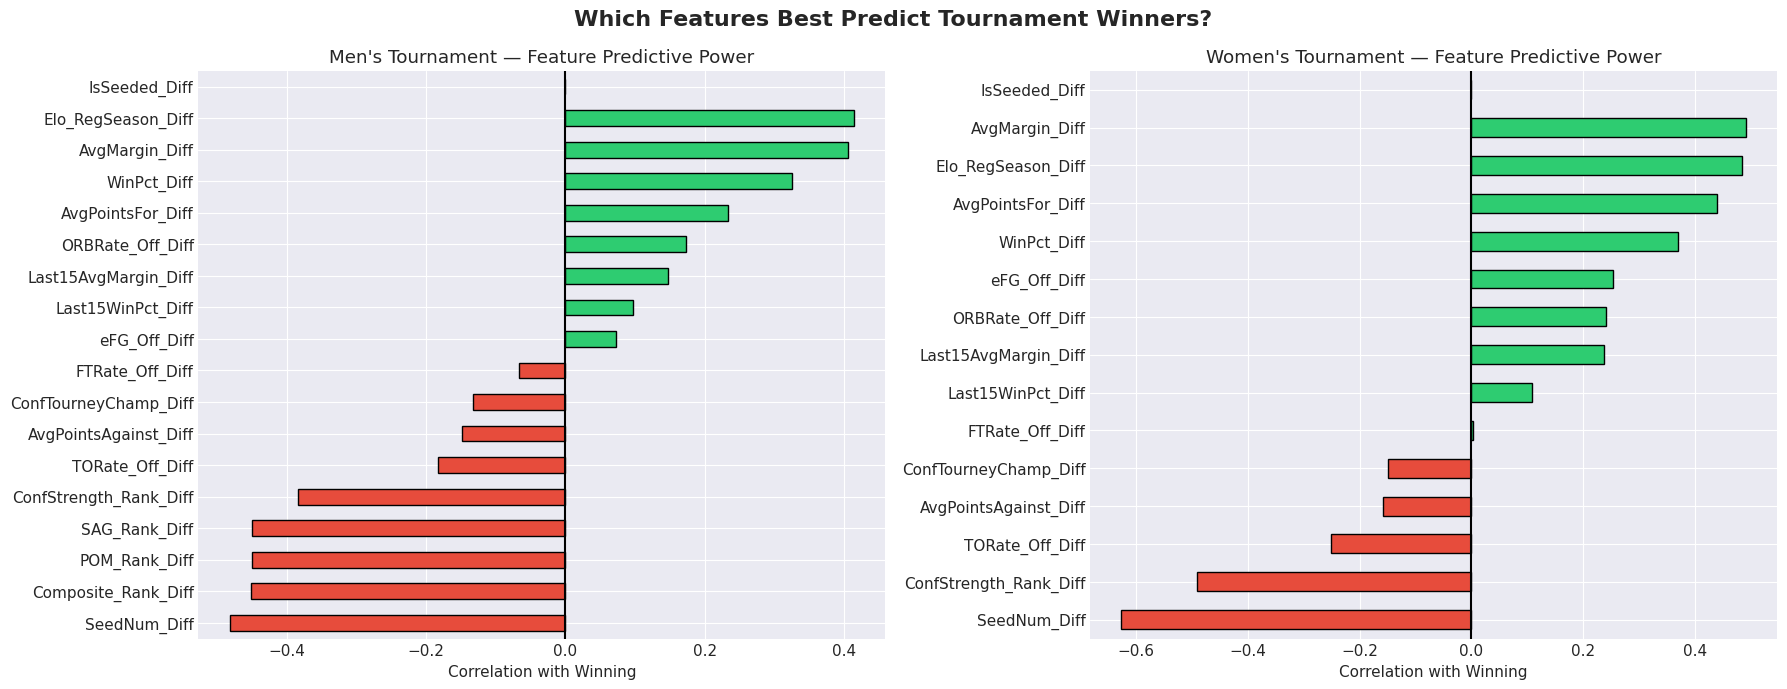

Longer bars = stronger predictor.
Green = positive diff helps Team1. Red = negative diff helps Team1 (inverted features like ranks).


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, data, title in [(axes[0], tmf_m, "Men's"), (axes[1], tmf_w, "Women's")]:
    diff_cols = [c for c in data.columns if c.endswith('_Diff')]
    target_corr = data[diff_cols + ['Target']].corr()['Target'].drop('Target').sort_values()
    
    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in target_corr.values]
    target_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
    ax.set_xlabel('Correlation with Winning')
    ax.set_title(f'{title} Tournament — Feature Predictive Power')
    ax.axvline(0, color='black', linestyle='-')

plt.suptitle('Which Features Best Predict Tournament Winners?', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Longer bars = stronger predictor.")
print("Green = positive diff helps Team1. Red = negative diff helps Team1 (inverted features like ranks).")

---
## 6. Feature Distributions — Winners vs Losers

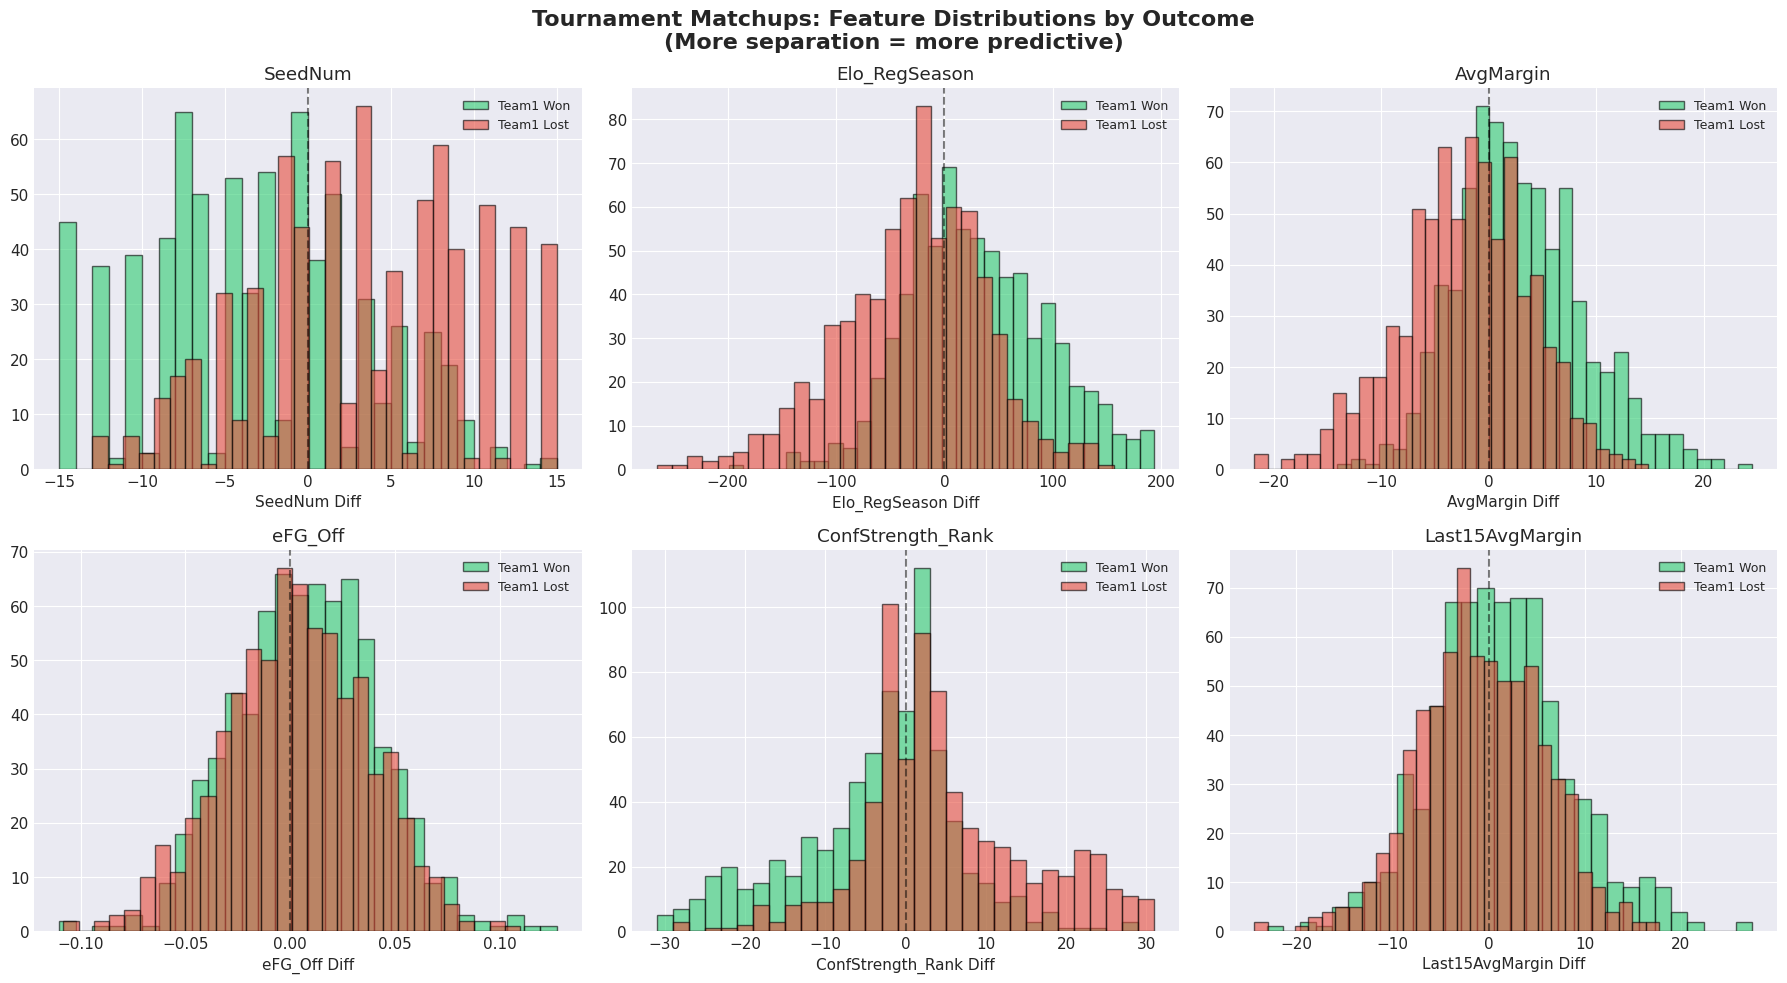

In [7]:
plot_features = ['SeedNum_Diff', 'Elo_RegSeason_Diff', 'AvgMargin_Diff',
                 'eFG_Off_Diff', 'ConfStrength_Rank_Diff', 'Last15AvgMargin_Diff']
available = [c for c in plot_features if c in tmf_m.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), available):
    wins = tmf_m[tmf_m['Target'] == 1][col].dropna()
    losses = tmf_m[tmf_m['Target'] == 0][col].dropna()
    
    ax.hist(wins, bins=30, alpha=0.6, label='Team1 Won', color='#2ecc71', edgecolor='black')
    ax.hist(losses, bins=30, alpha=0.6, label='Team1 Lost', color='#e74c3c', edgecolor='black')
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel(col.replace('_Diff', ' Diff'))
    ax.set_title(col.replace('_Diff', ''))
    ax.legend(fontsize=9)

plt.suptitle("Tournament Matchups: Feature Distributions by Outcome\n(More separation = more predictive)",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Feature Correlation Heatmap

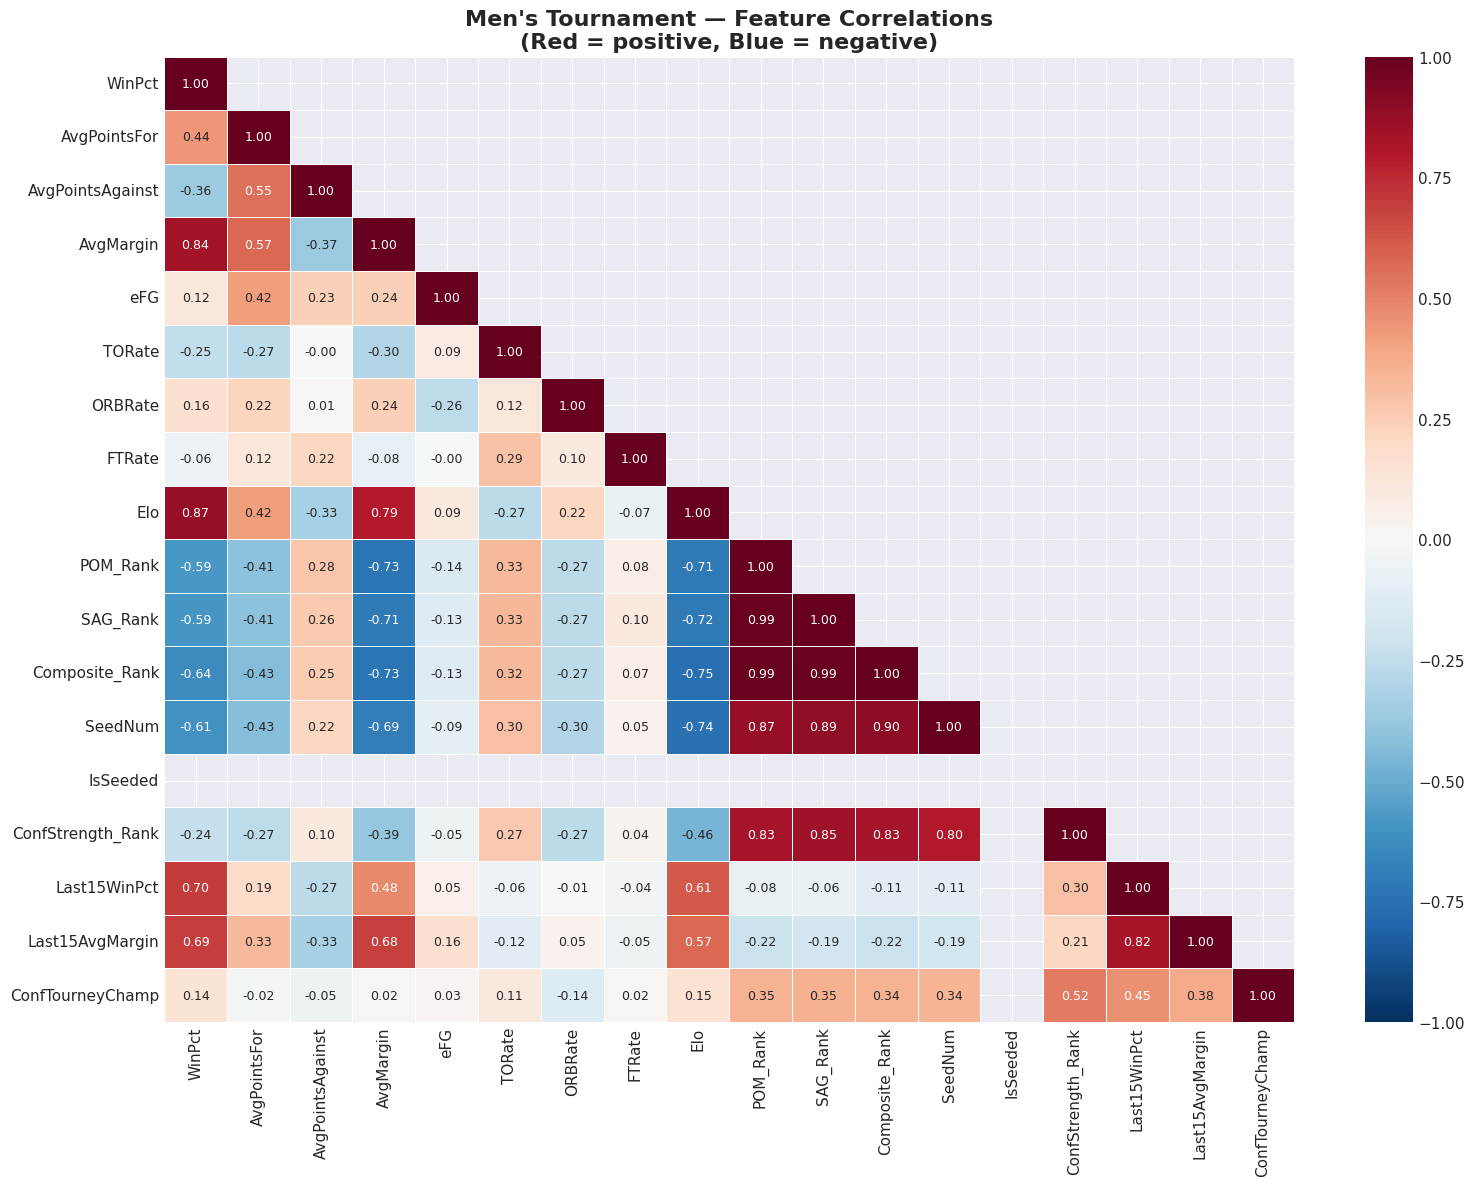


Highly correlated pairs (|r| > 0.7):
  WinPct_Diff                    <-> AvgMargin_Diff                : +0.84
  WinPct_Diff                    <-> Elo_RegSeason_Diff            : +0.87
  AvgMargin_Diff                 <-> Elo_RegSeason_Diff            : +0.79
  AvgMargin_Diff                 <-> POM_Rank_Diff                 : -0.73
  AvgMargin_Diff                 <-> SAG_Rank_Diff                 : -0.71
  AvgMargin_Diff                 <-> Composite_Rank_Diff           : -0.73
  Elo_RegSeason_Diff             <-> POM_Rank_Diff                 : -0.71
  Elo_RegSeason_Diff             <-> SAG_Rank_Diff                 : -0.72
  Elo_RegSeason_Diff             <-> Composite_Rank_Diff           : -0.75
  Elo_RegSeason_Diff             <-> SeedNum_Diff                  : -0.74
  POM_Rank_Diff                  <-> SAG_Rank_Diff                 : +0.99
  POM_Rank_Diff                  <-> Composite_Rank_Diff           : +0.99
  POM_Rank_Diff                  <-> SeedNum_Diff             

In [8]:
diff_cols = [c for c in tmf_m.columns if c.endswith('_Diff')]
corr = tmf_m[diff_cols].corr()

# Create a clean heatmap
fig, ax = plt.subplots(figsize=(16, 12))

# Short labels
short_labels = [c.replace('_Diff', '').replace('_Off', '').replace('_RegSeason', '')
                for c in diff_cols]

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=short_labels, yticklabels=short_labels,
            mask=mask, ax=ax, annot_kws={'size': 9},
            vmin=-1, vmax=1, linewidths=0.5)
ax.set_title("Men's Tournament — Feature Correlations\n(Red = positive, Blue = negative)",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print highly correlated pairs
print("\nHighly correlated pairs (|r| > 0.7):")
for i in range(len(diff_cols)):
    for j in range(i+1, len(diff_cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {diff_cols[i]:30s} <-> {diff_cols[j]:30s}: {r:+.2f}")

---
## 8. Conference Strength

/tmp/ipykernel_7041/2918904754.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(conf_data, labels=top_confs, patch_artist=True, vert=True)


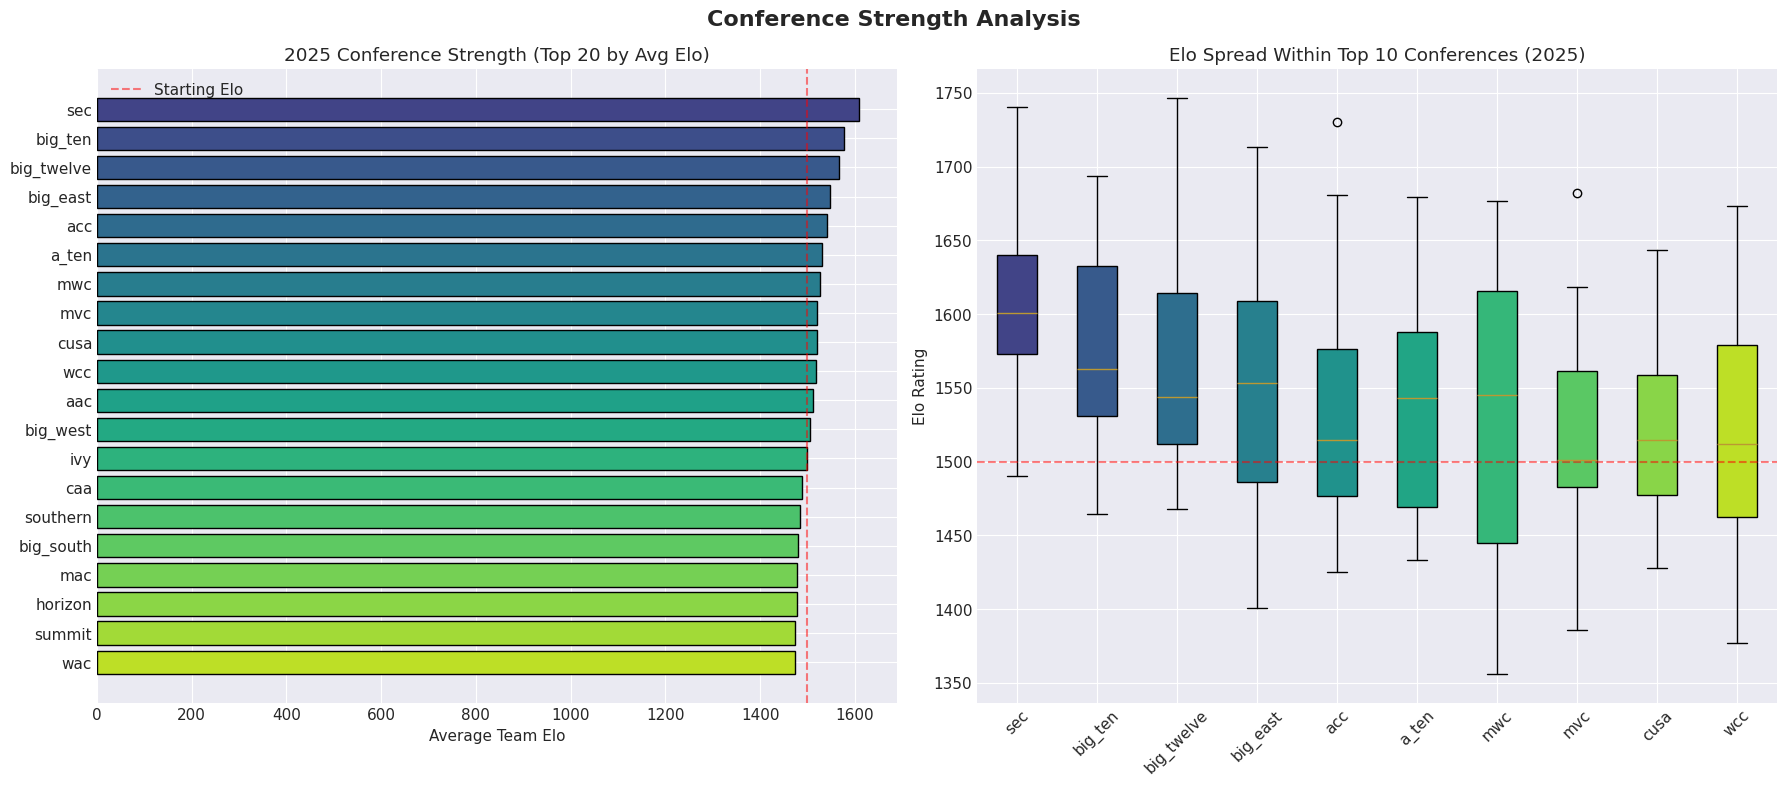

In [9]:
# Load conference data
conferences = pd.read_csv(DATA / 'MTeamConferences.csv')

# Get 2025 conference strength
conf_2025 = tf_m[tf_m['Season'] == 2025].merge(
    conferences[conferences['Season'] == 2025], on=['Season', 'TeamID'], how='left'
)

# Average stats per conference
conf_stats = conf_2025.groupby('ConfAbbrev').agg(
    AvgElo=('Elo_RegSeason', 'mean'),
    AvgWinPct=('WinPct', 'mean'),
    AvgMargin=('AvgMargin', 'mean'),
    Teams=('TeamID', 'count'),
    ConfRank=('ConfStrength_Rank', 'first')
).sort_values('AvgElo', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Conference Elo ranking
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(conf_stats)))
axes[0].barh(conf_stats.index[::-1], conf_stats['AvgElo'].values[::-1],
             color=colors[::-1], edgecolor='black')
axes[0].axvline(1500, color='red', linestyle='--', alpha=0.5, label='Starting Elo')
axes[0].set_xlabel('Average Team Elo')
axes[0].set_title('2025 Conference Strength (Top 20 by Avg Elo)')
axes[0].legend()

# Conference Elo spread (box plot style)
top_confs = conf_stats.head(10).index.tolist()
conf_data = [conf_2025[conf_2025['ConfAbbrev'] == c]['Elo_RegSeason'].values for c in top_confs]

bp = axes[1].boxplot(conf_data, labels=top_confs, patch_artist=True, vert=True)
for patch, color in zip(bp['boxes'], plt.cm.viridis(np.linspace(0.2, 0.9, 10))):
    patch.set_facecolor(color)
axes[1].axhline(1500, color='red', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Elo Rating')
axes[1].set_title('Elo Spread Within Top 10 Conferences (2025)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Conference Strength Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Late-Season Momentum

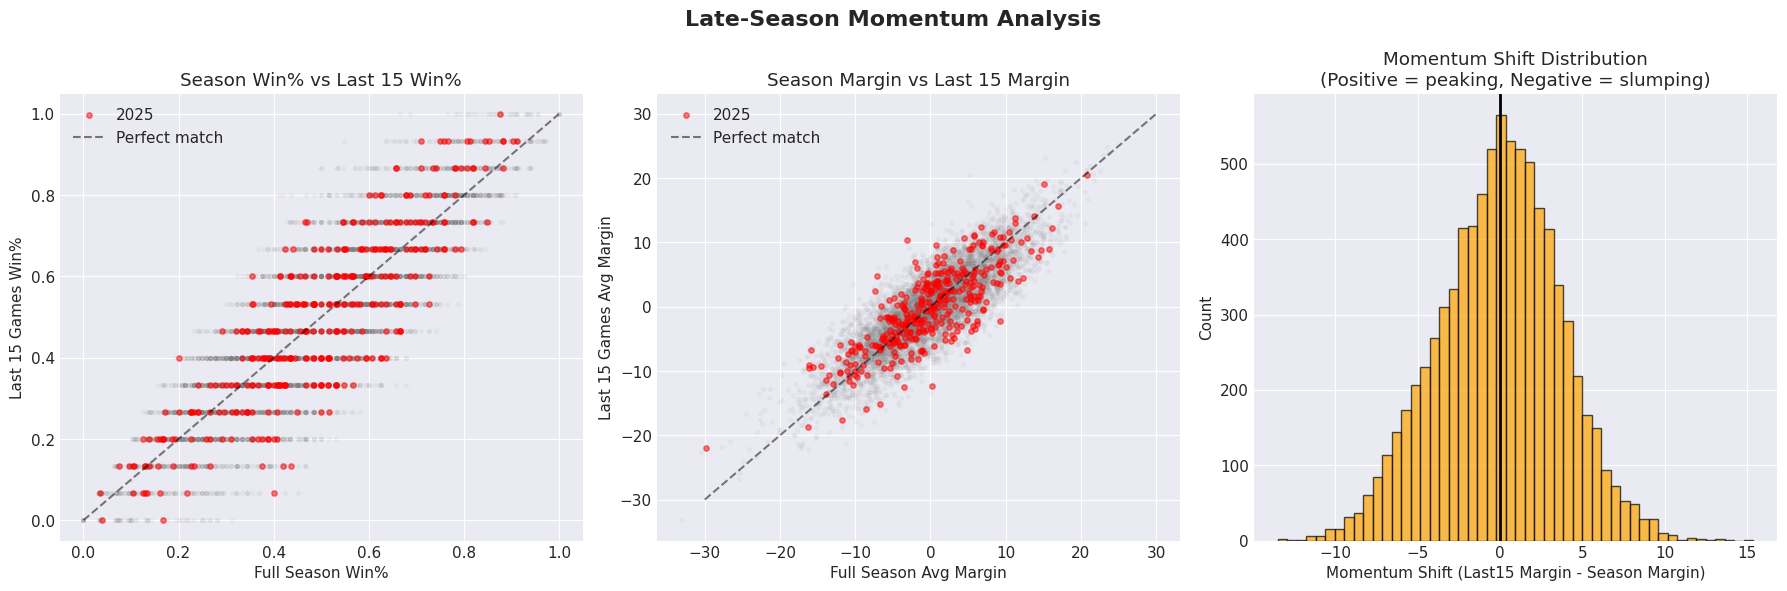

Points far from the diagonal = teams whose form changed late in the season.
These are the teams where the Last15 feature adds value over season averages.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Season vs Last15 WinPct
axes[0].scatter(tf_m['WinPct'], tf_m['Last15WinPct'], alpha=0.05, s=8, c='gray')
axes[0].scatter(season_2025['WinPct'], season_2025['Last15WinPct'],
                alpha=0.5, s=15, c='red', label='2025')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect match')
axes[0].set_xlabel('Full Season Win%')
axes[0].set_ylabel('Last 15 Games Win%')
axes[0].set_title('Season Win% vs Last 15 Win%')
axes[0].legend()

# Season vs Last15 Margin
axes[1].scatter(tf_m['AvgMargin'], tf_m['Last15AvgMargin'], alpha=0.05, s=8, c='gray')
axes[1].scatter(season_2025['AvgMargin'], season_2025['Last15AvgMargin'],
                alpha=0.5, s=15, c='red', label='2025')
axes[1].plot([-30, 30], [-30, 30], 'k--', alpha=0.5, label='Perfect match')
axes[1].set_xlabel('Full Season Avg Margin')
axes[1].set_ylabel('Last 15 Games Avg Margin')
axes[1].set_title('Season Margin vs Last 15 Margin')
axes[1].legend()

# Momentum difference (Last15 - Season)
tf_m_copy = tf_m.copy()
tf_m_copy['MomentumShift'] = tf_m_copy['Last15AvgMargin'] - tf_m_copy['AvgMargin']
axes[2].hist(tf_m_copy['MomentumShift'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[2].axvline(0, color='black', linestyle='-', linewidth=2)
axes[2].set_xlabel('Momentum Shift (Last15 Margin - Season Margin)')
axes[2].set_ylabel('Count')
axes[2].set_title('Momentum Shift Distribution\n(Positive = peaking, Negative = slumping)')

plt.suptitle('Late-Season Momentum Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Points far from the diagonal = teams whose form changed late in the season.")
print("These are the teams where the Last15 feature adds value over season averages.")

---
## 10. 2025 Top Teams Profile

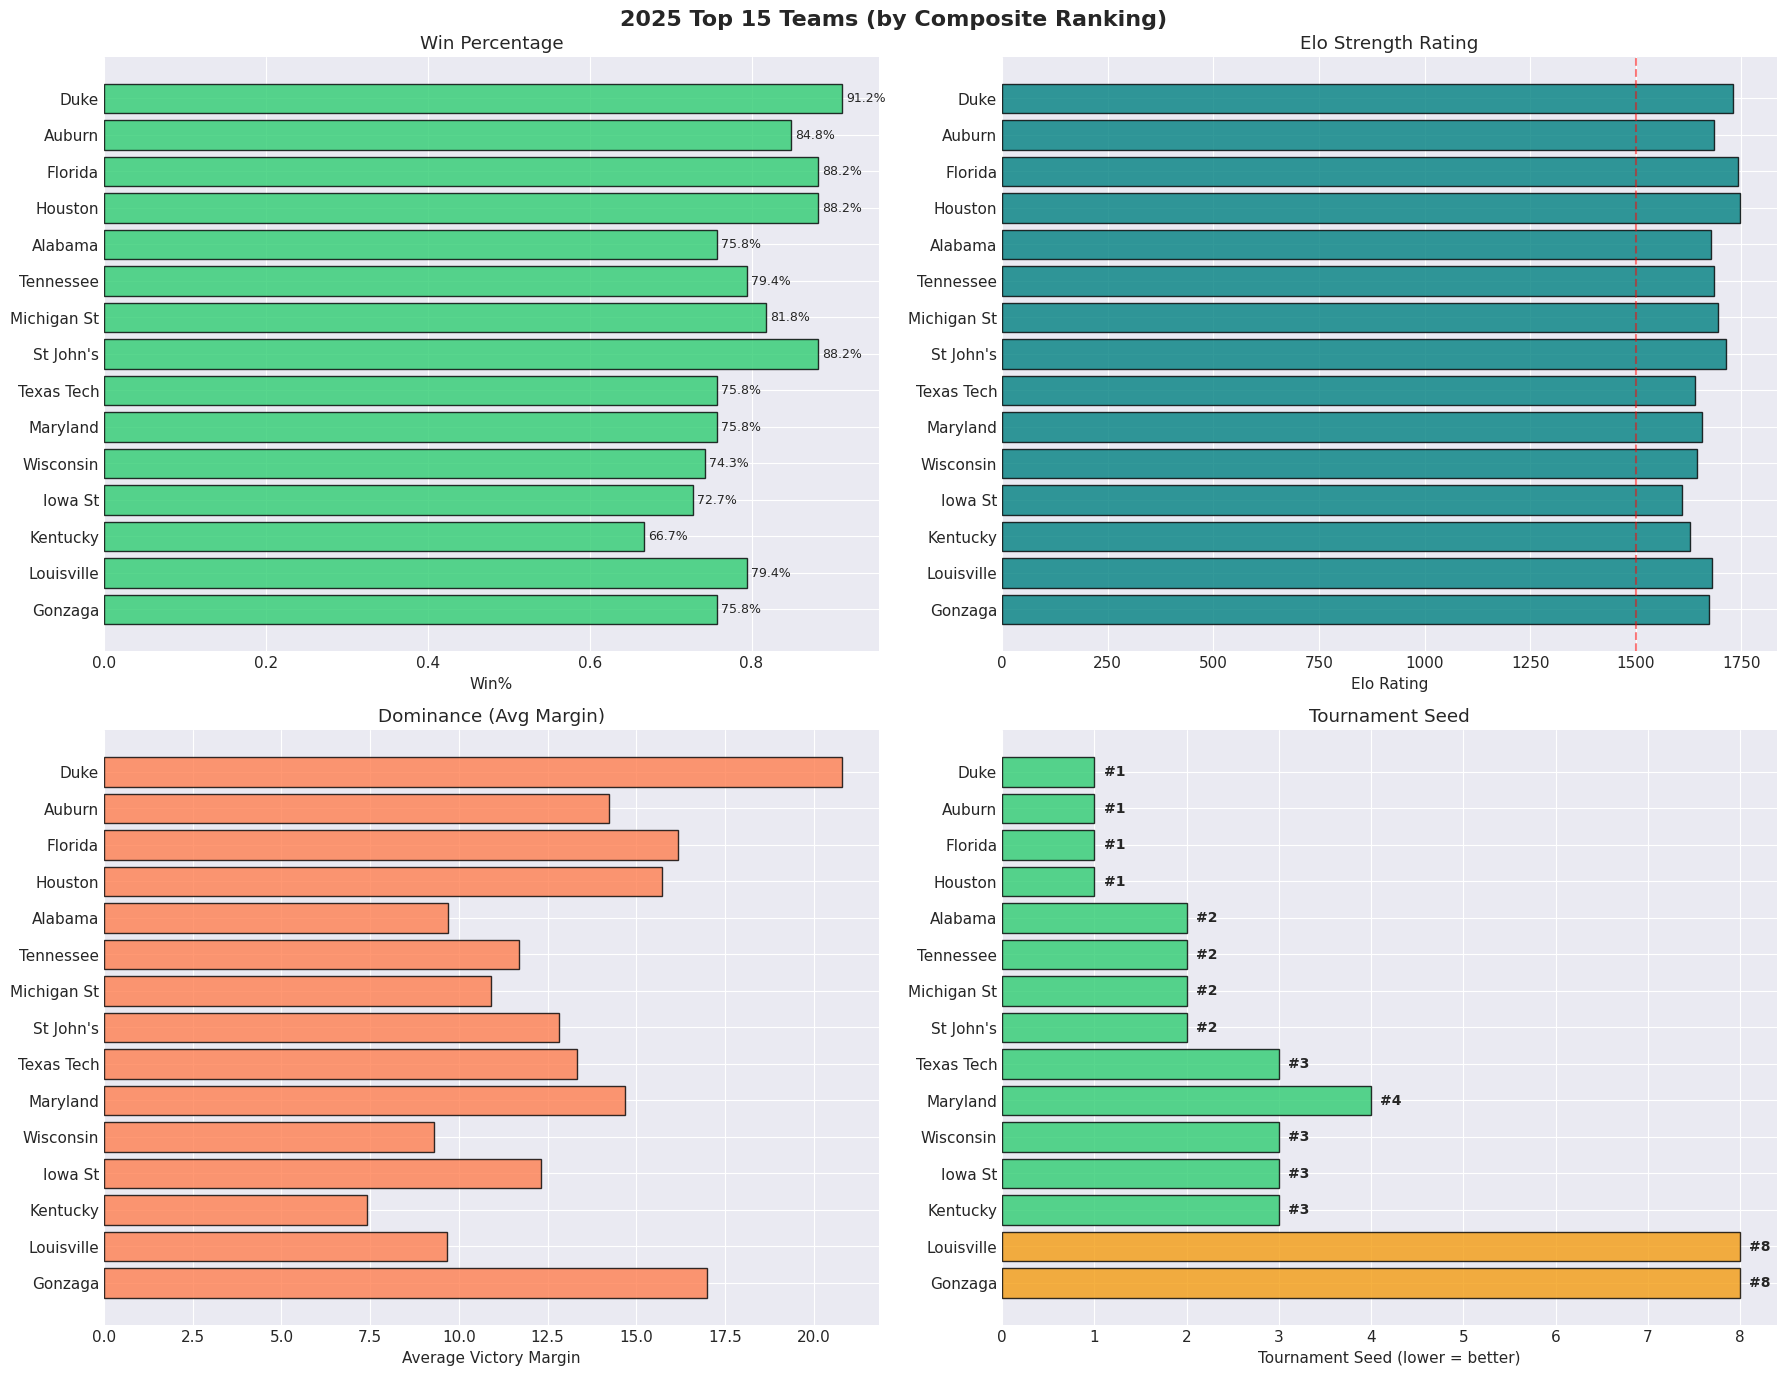

In [11]:
# Get top 15 teams by composite rank
top15 = season_2025.sort_values('Composite_Rank').head(15).copy()
top15['TeamName'] = top15['TeamID'].map(men_lookup)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Radar-style: multi-metric bar chart
metrics = ['WinPct', 'eFG_Off', 'Elo_RegSeason']
metric_labels = ['Win%', 'eFG%', 'Elo']

# Win% + Elo for top teams
y_pos = np.arange(len(top15))
axes[0, 0].barh(y_pos, top15['WinPct'].values, color='#2ecc71', edgecolor='black', alpha=0.8)
axes[0, 0].set_yticks(y_pos)
axes[0, 0].set_yticklabels(top15['TeamName'].values)
axes[0, 0].set_xlabel('Win%')
axes[0, 0].set_title('Win Percentage')
axes[0, 0].invert_yaxis()
for i, v in enumerate(top15['WinPct'].values):
    axes[0, 0].text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=9)

# Elo
axes[0, 1].barh(y_pos, top15['Elo_RegSeason'].values, color='teal', edgecolor='black', alpha=0.8)
axes[0, 1].set_yticks(y_pos)
axes[0, 1].set_yticklabels(top15['TeamName'].values)
axes[0, 1].set_xlabel('Elo Rating')
axes[0, 1].set_title('Elo Strength Rating')
axes[0, 1].invert_yaxis()
axes[0, 1].axvline(1500, color='red', linestyle='--', alpha=0.5)

# Avg Margin
axes[1, 0].barh(y_pos, top15['AvgMargin'].values, color='coral', edgecolor='black', alpha=0.8)
axes[1, 0].set_yticks(y_pos)
axes[1, 0].set_yticklabels(top15['TeamName'].values)
axes[1, 0].set_xlabel('Average Victory Margin')
axes[1, 0].set_title('Dominance (Avg Margin)')
axes[1, 0].invert_yaxis()

# Seed
seed_colors = ['#2ecc71' if s <= 4 else '#f39c12' if s <= 8 else '#e74c3c'
               for s in top15['SeedNum'].values]
axes[1, 1].barh(y_pos, top15['SeedNum'].values, color=seed_colors, edgecolor='black', alpha=0.8)
axes[1, 1].set_yticks(y_pos)
axes[1, 1].set_yticklabels(top15['TeamName'].values)
axes[1, 1].set_xlabel('Tournament Seed (lower = better)')
axes[1, 1].set_title('Tournament Seed')
axes[1, 1].invert_yaxis()
for i, v in enumerate(top15['SeedNum'].values):
    axes[1, 1].text(v + 0.1, i, f'#{int(v)}', va='center', fontsize=10, fontweight='bold')

plt.suptitle('2025 Top 15 Teams (by Composite Ranking)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Men's vs Women's Comparison

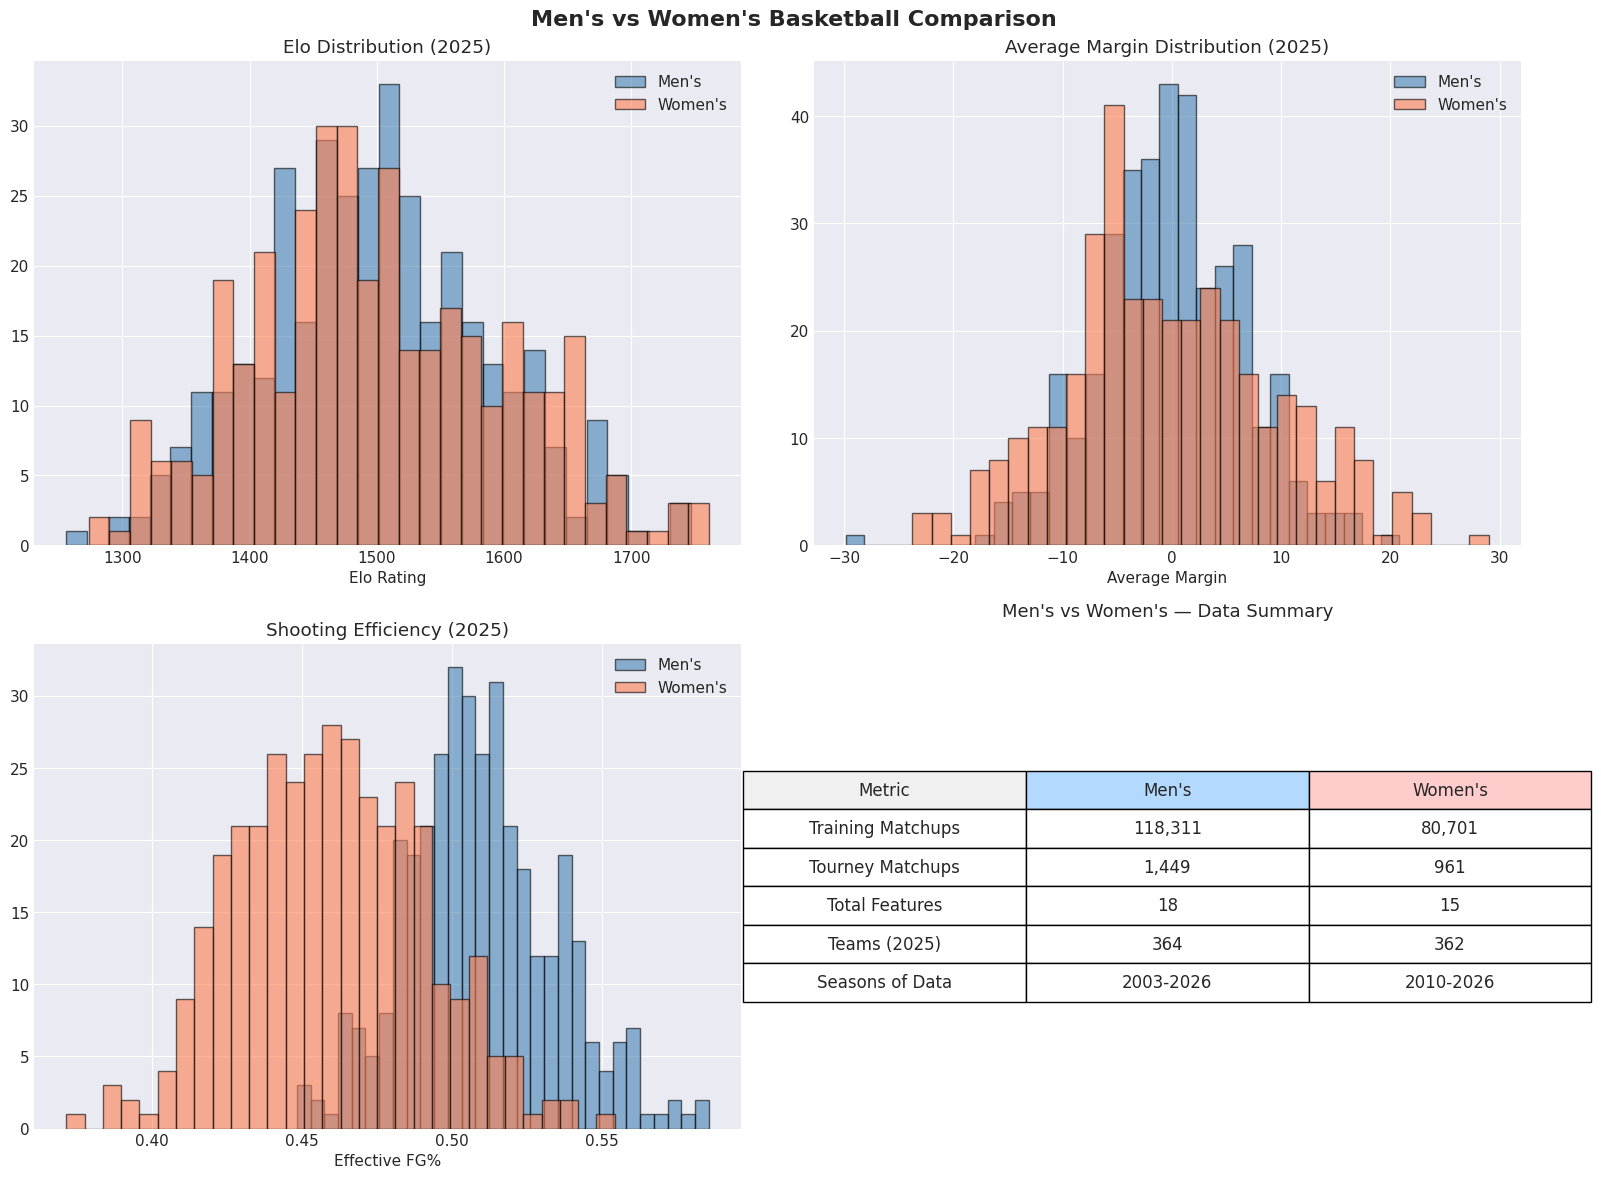

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

m_25 = tf_m[tf_m['Season'] == 2025]
w_25 = tf_w[tf_w['Season'] == 2025]

# Elo comparison
axes[0, 0].hist(m_25['Elo_RegSeason'], bins=30, alpha=0.6, label="Men's",
                color='steelblue', edgecolor='black')
axes[0, 0].hist(w_25['Elo_RegSeason'], bins=30, alpha=0.6, label="Women's",
                color='coral', edgecolor='black')
axes[0, 0].set_xlabel('Elo Rating')
axes[0, 0].set_title('Elo Distribution (2025)')
axes[0, 0].legend()

# AvgMargin comparison
axes[0, 1].hist(m_25['AvgMargin'], bins=30, alpha=0.6, label="Men's",
                color='steelblue', edgecolor='black')
axes[0, 1].hist(w_25['AvgMargin'], bins=30, alpha=0.6, label="Women's",
                color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Average Margin')
axes[0, 1].set_title('Average Margin Distribution (2025)')
axes[0, 1].legend()

# eFG comparison
axes[1, 0].hist(m_25['eFG_Off'], bins=30, alpha=0.6, label="Men's",
                color='steelblue', edgecolor='black')
axes[1, 0].hist(w_25['eFG_Off'], bins=30, alpha=0.6, label="Women's",
                color='coral', edgecolor='black')
axes[1, 0].set_xlabel('Effective FG%')
axes[1, 0].set_title('Shooting Efficiency (2025)')
axes[1, 0].legend()

# Feature count comparison
m_diff = [c for c in tmf_m.columns if c.endswith('_Diff')]
w_diff = [c for c in tmf_w.columns if c.endswith('_Diff')]

comparison_data = {
    'Metric': ['Training Matchups', 'Tourney Matchups', 'Total Features',
               'Teams (2025)', 'Seasons of Data'],
    "Men's": [f'{len(mf_m):,}', f'{len(tmf_m):,}', str(len(m_diff)),
              str(len(m_25)), f"{tf_m['Season'].min()}-{tf_m['Season'].max()}"],
    "Women's": [f'{len(mf_w):,}', f'{len(tmf_w):,}', str(len(w_diff)),
                str(len(w_25)), f"{tf_w['Season'].min()}-{tf_w['Season'].max()}"],
}
comp_df = pd.DataFrame(comparison_data)

axes[1, 1].axis('off')
table = axes[1, 1].table(
    cellText=comp_df.values,
    colLabels=comp_df.columns,
    cellLoc='center',
    loc='center',
    colColours=['#f0f0f0', '#b3d9ff', '#ffcccc']
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)
axes[1, 1].set_title("Men's vs Women's — Data Summary", fontsize=13, pad=20)

plt.suptitle("Men's vs Women's Basketball Comparison", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. Elo Rating Evolution — Top Teams Over Time

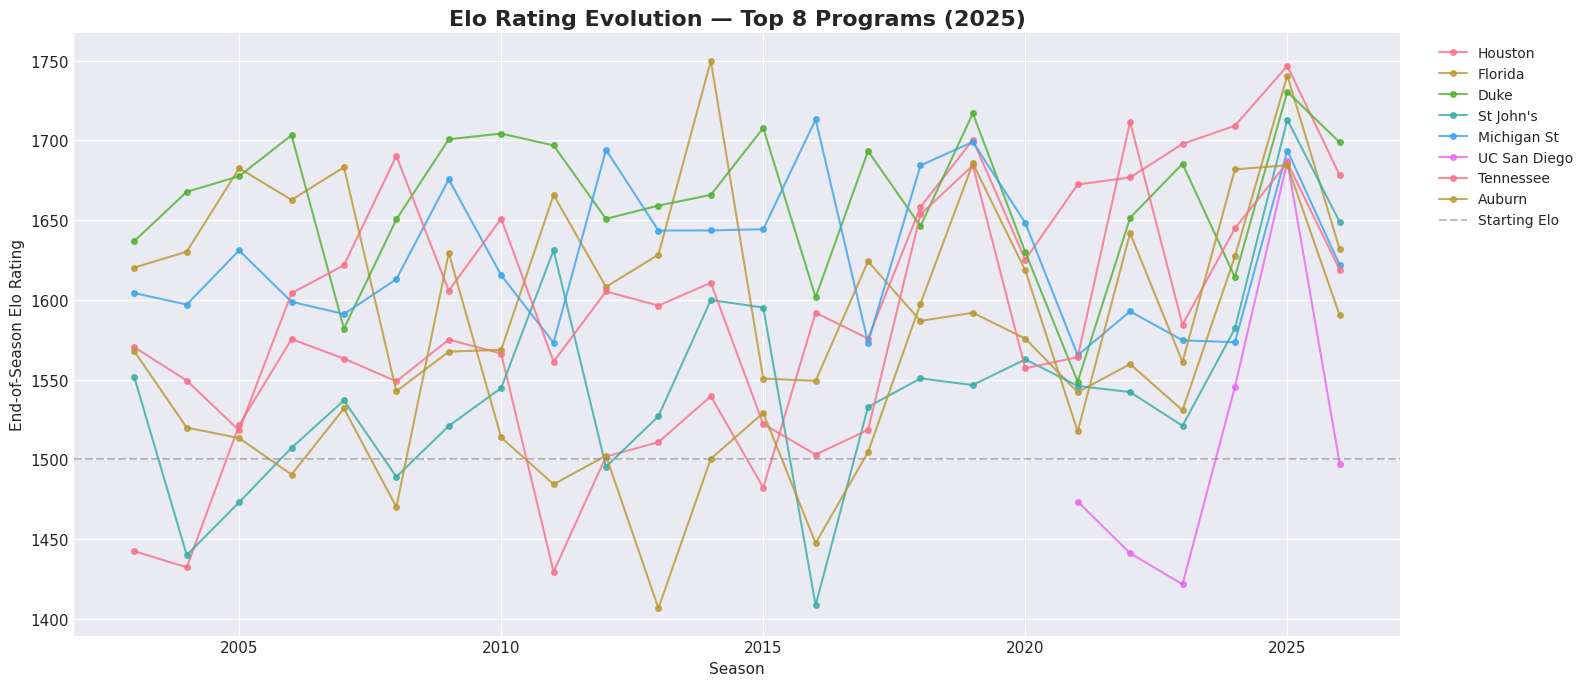

In [13]:
# Track Elo for historically strong programs
top_programs = season_2025.sort_values('Elo_RegSeason', ascending=False).head(8)['TeamID'].tolist()

fig, ax = plt.subplots(figsize=(16, 7))

for team_id in top_programs:
    team_data = tf_m[tf_m['TeamID'] == team_id].sort_values('Season')
    name = men_lookup.get(team_id, str(team_id))
    ax.plot(team_data['Season'], team_data['Elo_RegSeason'], 'o-',
            label=name, markersize=4, linewidth=1.5, alpha=0.8)

ax.axhline(1500, color='gray', linestyle='--', alpha=0.5, label='Starting Elo')
ax.set_xlabel('Season')
ax.set_ylabel('End-of-Season Elo Rating')
ax.set_title('Elo Rating Evolution — Top 8 Programs (2025)', fontsize=16, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

---

*Dashboard generated from processed feature data. Run the feature building notebooks (04a, 04b) first to populate the processed/ directory.*